In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#import seaborn as sns

url='sales.txt'
df=pd.read_csv(url, sep='\s+',header=None)
print(df.shape)
print(df.head())
df.columns=['Sales','Advertising']
print(df.head())
print(df.info())


(36, 2)
      0     1
0  12.0  15.0
1  20.5  16.0
2  21.0  18.0
3  15.5  27.0
4  15.3  21.0
   Sales  Advertising
0   12.0         15.0
1   20.5         16.0
2   21.0         18.0
3   15.5         27.0
4   15.3         21.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Sales        36 non-null     float64
 1   Advertising  36 non-null     float64
dtypes: float64(2)
memory usage: 708.0 bytes
None


<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-6579388.py:7: SyntaxWarning: invalid escape sequence '\s'
  df=pd.read_csv(url, sep='\s+',header=None)


In [12]:
print(df.describe())

           Sales  Advertising
count  36.000000    36.000000
mean   24.255556    28.527778
std     6.185118    18.777625
min    12.000000     1.000000
25%    20.300000    15.750000
50%    24.250000    23.000000
75%    28.600000    41.000000
max    36.500000    65.000000


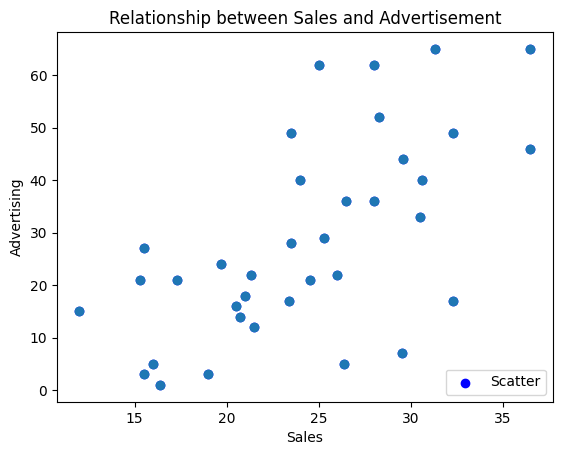

In [17]:
x=df['Sales'].values
y=df['Advertising'].values
plt.scatter(x,y, color='blue',label='Scatter')
plt.xlabel('Sales')
plt.ylabel('Advertising')
plt.title('Relationship between Sales and Advertisement')
plt.legend(loc=4)
plt.scatter(x,y)
plt.show()

In [19]:
print(x.shape)
print(y.shape)
x=x.reshape(-1,1)
y=y.reshape(-1,1)
print(x.shape)
print(y.shape)

(36,)
(36,)
(36, 1)
(36, 1)


In [20]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.33,random_state=42)
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(24, 1)
(24, 1)
(12, 1)
(12, 1)


In [22]:
from sklearn.linear_model import LinearRegression
lm = LinearRegression()
lm.fit(x_train,y_train)
y_pred=lm.predict(x_test)
print(y_pred)

[[15.16349678]
 [29.44882869]
 [31.37494085]
 [34.2641091 ]
 [47.42587557]
 [39.07938952]
 [23.34947349]
 [16.60808091]
 [26.55966044]
 [36.35073062]
 [33.78258106]
 [26.39915109]]


In [23]:
a=lm.coef_
b=lm.intercept_
print("Estimate model slope, a:", a)
print("Estimate model intercept, b:", b)


Estimate model slope, a: [[1.60509347]]
Estimate model intercept, b: [-11.16003616]


In [24]:
lm .predict(x)[0:5]

array([[ 8.10108551],
       [21.74438002],
       [22.54692675],
       [13.71891266],
       [13.39789396]])

In [27]:
import numpy as np # Import numpy to create a 2D array
print(str(lm.predict([[24]]))) # Reshape the input to a 2D array

[[27.36220717]]


In [31]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("RMSE value: {:.4f}".format(rmse))

RMSE value: 11.2273


In [34]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print("R2 score value: {:.4f}".format(r2))

R2 score value: 0.5789


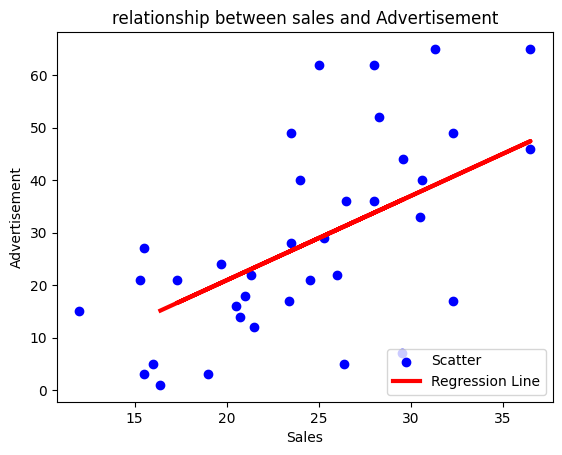

In [37]:
plt.scatter(x,y, color='blue',label='Scatter')
plt.plot(x_test,y_pred,color='red',linewidth=3,label='Regression Line')
plt.title('relationship between sales and Advertisement')
plt.xlabel('Sales')
plt.ylabel('Advertisement')
plt.legend(loc=4)
plt.show()

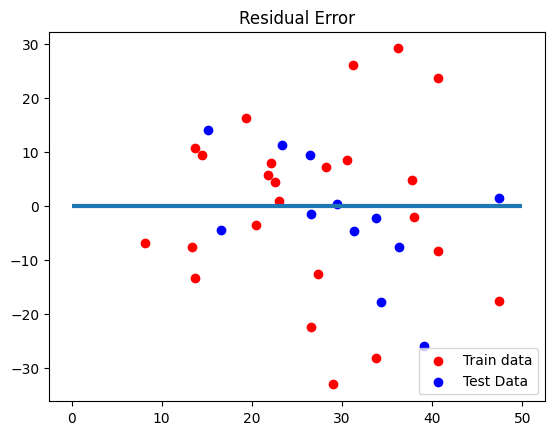

In [39]:
plt.scatter(lm.predict(x_train),lm.predict(x_train)-y_train,color='red',label='Train data')
plt.scatter(lm.predict(x_test),lm.predict(x_test)-y_test,color='blue',label='Test Data')
plt.hlines(xmin=0,xmax=50,y=0,linewidth=3)
plt.title('Residual Error')
plt.legend(loc=4)
plt.show()

In [40]:
print("Training set score:{:.4f}".format(lm.score(x_train,y_train)))
print("Test set score: {:.4f}".format(lm.score(x_test,y_test)))

Training set score:0.2861
Test set score: 0.5789
